# Part 1: Privacy-Preserving Heart Disease Prediction using Federated Learning

This notebook demonstrates the core functionality, evaluating multiple models both centrally and federally to maximize accuracy on our dataset.

## 1. Imports & Directory Setup

In [ ]:
import pandas as pd
import numpy as np
import joblib
import os
import json
import threading
import time
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, log_loss
import flwr as fl
from typing import Dict, List, Optional, Tuple
from flwr.common import Metrics

os.makedirs("data", exist_ok=True)
os.makedirs("model", exist_ok=True)
os.makedirs("results", exist_ok=True)
print("Directories ready.")

## 2. Download & Preprocess Data

In [ ]:
print("Downloading and reading UCI Heart Disease dataset...")
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
columns = ["age", "sex", "cp", "trestbps", "chol", "fbs", "restecg", "thalach", "exang", "oldpeak", "slope", "ca", "thal", "target"]
df = pd.read_csv(url, header=None, names=columns, na_values="?")

df['target'] = (df['target'] > 0).astype(int)
X = df.drop("target", axis=1)
y = df["target"]

categorical_cols = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]
numerical_cols = ["age", "trestbps", "chol", "thalach", "oldpeak"]

numeric_transformer = Pipeline(steps=[("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())])
categorical_transformer = Pipeline(steps=[("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))])
preprocessor = ColumnTransformer(transformers=[("num", numeric_transformer, numerical_cols), ("cat", categorical_transformer, categorical_cols)])

X_processed = preprocessor.fit_transform(X)
joblib.dump(preprocessor, "model/preprocessor.joblib")

if hasattr(X_processed, "toarray"):
    X_processed = X_processed.toarray()
processed_df = pd.DataFrame(X_processed)
processed_df["target"] = y.values
processed_df.to_csv("data/processed_data.csv", index=False)
print(f"Data preprocessed and saved. Shape: {processed_df.shape}")

## 3. Split Data for Simulated Hospitals

In [ ]:
df = pd.read_csv("data/processed_data.csv")
df_shuffled = df.sample(frac=1, random_state=42).reset_index(drop=True)
chunks = np.array_split(df_shuffled, 4)

for i, chunk in enumerate(chunks, 1):
    client_dir = f"data/hospital_{i}"
    os.makedirs(client_dir, exist_ok=True)
    chunk.to_csv(f"{client_dir}/train.csv", index=False)
    print(f"Saved hospital_{i} data with shape {chunk.shape}")

## 4. Train Centralized Baseline Models
To find the highest theoretical accuracy, we test 4 different centralized models.

In [ ]:
df = pd.read_csv("data/processed_data.csv")
X = df.drop("target", axis=1).values
y = df["target"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

centralized_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "Neural Network (MLP)": MLPClassifier(hidden_layer_sizes=(16,), max_iter=1000, random_state=42)
}

results = []
for name, model in centralized_models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results.append({"Model": name, "Centralized Accuracy": f"{acc*100:.2f}%"})
    joblib.dump(model, f"results/centralized_{name.replace(' ', '_')}.joblib")

centralized_df = pd.DataFrame(results)
print("\n--- Centralized Baselines ---")
print(centralized_df.to_string(index=False))

## 5. Federated Learning Simulation (Testing Multiple Models)
Not all models work with FedAvg (e.g. Random Forests). Here we run 3 separate FL simulations for models that support mathematical weight averaging (Logistic Regression, Linear SGD, and Neural Network).

In [15]:
def get_model_params(model):
    if hasattr(model, "coef_"):
        return [model.coef_, model.intercept_]
    elif hasattr(model, "coefs_"):
        return model.coefs_ + model.intercepts_
    return []

def set_model_params(model, parameters):
    if hasattr(model, "coef_"):
        model.coef_ = parameters[0]
        model.intercept_ = parameters[1]
    elif hasattr(model, "coefs_"):
        num_layers = len(model.coefs_)
        model.coefs_ = parameters[:num_layers]
        model.intercepts_ = parameters[num_layers:]
    if not hasattr(model, "classes_"):
        model.classes_ = np.array([0, 1])

class HeartDiseaseClient(fl.client.NumPyClient):
    def __init__(self, model, X_train, y_train, X_test, y_test):
        self.model = model
        self.X_train = X_train
        self.y_train = y_train
        self.X_test = X_test
        self.y_test = y_test

    def get_parameters(self, config):
        return get_model_params(self.model)

    def fit(self, parameters, config):
        set_model_params(self.model, parameters)
        self.model.fit(self.X_train, self.y_train)
        return self.get_parameters(config={}), len(self.X_train), {}

    def evaluate(self, parameters, config):
        set_model_params(self.model, parameters)
        y_pred = self.model.predict(self.X_test)
        if hasattr(self.model, "predict_proba"):
            y_prob = self.model.predict_proba(self.X_test)
            loss = log_loss(self.y_test, y_prob)
        else:
            loss = 1.0 # fallback
        accuracy = accuracy_score(self.y_test, y_pred)
        return float(loss), len(self.X_test), {"accuracy": float(accuracy)}

def evaluate_metrics_aggregation_fn(metrics: List[Tuple[int, Metrics]]) -> Metrics:
    accuracies = [num_examples * m["accuracy"] for num_examples, m in metrics]
    examples = [num_examples for num_examples, _ in metrics]
    return {"accuracy": sum(accuracies) / sum(examples)}

fl_models = {
    "Logistic Regression": lambda n_feat: LogisticRegression(max_iter=1, warm_start=True, solver="saga", random_state=42),
    "Linear SGD": lambda n_feat: SGDClassifier(loss='log_loss', max_iter=1, warm_start=True, random_state=42),
    "Neural Network (MLP)": lambda n_feat: MLPClassifier(hidden_layer_sizes=(16,), max_iter=15, warm_start=True, random_state=42)
}

def initialize_fl_model(model_name, n_features):
    model = fl_models[model_name](n_features)
    if model_name == "Neural Network (MLP)":
        X_dummy = np.zeros((2, n_features))
        y_dummy = np.array([0, 1])
        model.partial_fit(X_dummy, y_dummy, classes=np.array([0, 1]))
    else:
        model.classes_ = np.array([0, 1])
        model.coef_ = np.zeros((1, n_features))
        model.intercept_ = np.zeros(1)
    return model

fl_results_history = {}
PORT = 8080

for model_name in fl_models.keys():
    print(f"\n{'='*40}\nRunning FL Simulation for: {model_name}\n{'='*40}")
    PORT += 1
    
    global_metrics = {"round": [], "loss": [], "accuracy": []}
    
    class SaveModelStrategy(fl.server.strategy.FedAvg):
        def aggregate_fit(self, server_round, results, failures):
            aggregated_parameters, aggregated_metrics = super().aggregate_fit(server_round, results, failures)
            return aggregated_parameters, aggregated_metrics
            
        def aggregate_evaluate(self, server_round, results, failures):
            loss, metrics = super().aggregate_evaluate(server_round, results, failures)
            if loss is not None and metrics is not None:
                global_metrics["round"].append(server_round)
                global_metrics["loss"].append(loss)
                global_metrics["accuracy"].append(metrics["accuracy"])
            return loss, metrics

    strategy = SaveModelStrategy(
        fraction_fit=1.0, fraction_evaluate=1.0,
        min_fit_clients=4, min_evaluate_clients=4, min_available_clients=4,
        evaluate_metrics_aggregation_fn=evaluate_metrics_aggregation_fn,
    )

    def run_server():
        fl.server.start_server(server_address=f"127.0.0.1:{PORT}", config=fl.server.ServerConfig(num_rounds=5), strategy=strategy)

    def run_client(cid):
        client_id = int(cid) + 1
        df = pd.read_csv(f"data/hospital_{client_id}/train.csv")
        X = df.drop("target", axis=1).values
        y = df["target"].values
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
        model = initialize_fl_model(model_name, X_train.shape[1])
        client = HeartDiseaseClient(model, X_train, y_train, X_test, y_test).to_client()
        fl.client.start_client(server_address=f"127.0.0.1:{PORT}", client=client)

    def delayed_start_clients():
        time.sleep(3)
        print(f"Starting 4 Clients for {model_name}...")
        client_threads = []
        for i in range(4):
            t = threading.Thread(target=run_client, args=(i,))
            t.start()
            client_threads.append(t)
        for t in client_threads:
            t.join()
        print(f"All clients finished for {model_name}.")

    client_launcher_thread = threading.Thread(target=delayed_start_clients)
    client_launcher_thread.start()
    run_server()
    client_launcher_thread.join()
    
    fl_results_history[model_name] = global_metrics
    pd.DataFrame(global_metrics).to_csv(f"results/federated_metrics_{model_name.replace(' ', '_')}.csv", index=False)

print("\nAll FL Simulations Finished!")

	Instead, use the `flower-superlink` CLI command to start a SuperLink as shown below:

		$ flower-superlink --insecure

	To view usage and all available options, run:

		$ flower-superlink --help

	Using `start_server()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
INFO :      Starting Flower server, config: num_rounds=5, no round_timeout
INFO :      Flower ECE: gRPC server running (5 rounds), SSL is disabled
INFO :      [INIT]
INFO :      Requesting initial parameters from one random client



Running FL Simulation for: Logistic Regression


	Instead, use the `flower-supernode` CLI command to start a SuperNode as shown below:

		$ flower-supernode --insecure --superlink='<IP>:<PORT>'

	To view all available options, run:

		$ flower-supernode --help

	Using `start_client()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
	Instead, use the `flower-supernode` CLI command to start a SuperNode as shown below:

		$ flower-supernode --insecure --superlink='<IP>:<PORT>'

	To view all available options, run:

		$ flower-supernode --help

	Using `start_client()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
	Instead, use the `flower-supernode` CLI command to start a SuperNode as shown below:

		$ flower-supernode --insecure --superlink='<IP>:<PORT>'

	To view all available options, run:

		$ flower-supernode --help

	Using `start_client()` is deprecated.


Starting 4 Clients for Logistic Regression...


INFO :      
INFO :      Received: evaluate message 273ff4f6-5a25-40ce-b467-098594ba13ab
INFO :      Sent reply
INFO :      Received: evaluate message 260a8c1b-1cd1-4a67-992f-e64c283ae97c
INFO :      Received: evaluate message 35188b76-0927-4625-beae-f2ee336d16cf
INFO :      Sent reply
INFO :      Sent reply
INFO :      Sent reply
INFO :      aggregate_evaluate: received 4 results and 0 failures
INFO :      
INFO :      [ROUND 2]
INFO :      configure_fit: strategy sampled 4 clients (out of 4)
INFO :      
INFO :      Received: train message 284d1bdb-7b8d-4e69-bc91-4c281a7d1534
INFO :      
c:\Users\Prathyush\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
INFO :      
INFO :      
INFO :      Sent reply
INFO :      Received: train message ed3a8108-6bdd-4712-ab3f-656776783653
INFO :      Received: train message 75dc4294-de0f-444b-82ab-d43328a2

...

All clients finished for Linear SGD.

Running FL Simulation for: Neural Network (MLP)


	Instead, use the `flower-supernode` CLI command to start a SuperNode as shown below:

		$ flower-supernode --insecure --superlink='<IP>:<PORT>'

	To view all available options, run:

		$ flower-supernode --help

	Using `start_client()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
	Instead, use the `flower-supernode` CLI command to start a SuperNode as shown below:

		$ flower-supernode --insecure --superlink='<IP>:<PORT>'

	To view all available options, run:

		$ flower-supernode --help

	Using `start_client()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
INFO :      
	Instead, use the `flower-supernode` CLI command to start a SuperNode as shown below:

		$ flower-supernode --insecure --superlink='<IP>:<PORT>'

	To view all available options, run:

		$ flower-supernode --help

	Using `start_client()` is

Starting 4 Clients for Neural Network (MLP)...


INFO :      Sent reply
INFO :      Sent reply
INFO :      aggregate_fit: received 4 results and 0 failures
INFO :      configure_evaluate: strategy sampled 4 clients (out of 4)
INFO :      
INFO :      
INFO :      
INFO :      Received: evaluate message 4acca68c-590b-4fc5-b3e7-86ec7e518ac2
INFO :      
INFO :      Received: evaluate message 95364bb8-52c5-4580-954f-21a57633ec94
INFO :      Received: evaluate message 513fb2bf-78eb-4fb7-9d03-7c4bed2358f2
INFO :      Sent reply
INFO :      Received: evaluate message f6b3b799-5eac-4ee0-b2de-1859b132e249
INFO :      Sent reply
INFO :      Sent reply
INFO :      Sent reply
INFO :      aggregate_evaluate: received 4 results and 0 failures
INFO :      
INFO :      [ROUND 2]
INFO :      configure_fit: strategy sampled 4 clients (out of 4)
INFO :      
INFO :      Received: train message 10dd0b40-bd8b-46cb-b886-2066040a3e56
INFO :      
INFO :      
INFO :      
INFO :      Received: train message 73591a9f-99a5-4231-b4df-01859b476695
INFO :     

All clients finished for Neural Network (MLP).

All FL Simulations Finished!


## 6. Final Evaluation & Convergence Comparison

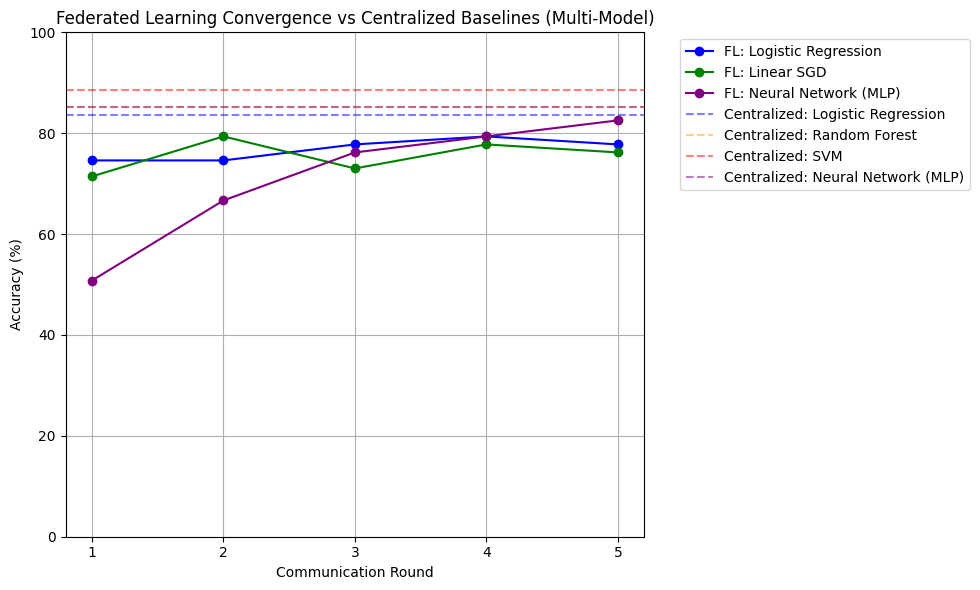

In [16]:
plt.figure(figsize=(10, 6))

colors = ['blue', 'green', 'purple']
for (model_name, metrics), color in zip(fl_results_history.items(), colors):
    plt.plot(metrics['round'], np.array(metrics['accuracy']) * 100, marker='o', label=f'FL: {model_name}', color=color)
    
# Plot the Centralized Baselines as dashed lines for comparison
baseline_colors = {'Logistic Regression': 'blue', 'Random Forest': 'orange', 'SVM': 'red', 'Neural Network (MLP)': 'purple'}
for _, row in centralized_df.iterrows():
    name = row['Model']
    acc = float(row['Centralized Accuracy'].replace('%', ''))
    if name in baseline_colors:
        plt.axhline(y=acc, color=baseline_colors[name], linestyle='--', alpha=0.5, label=f'Centralized: {name}')

plt.title('Federated Learning Convergence vs Centralized Baselines (Multi-Model)')
plt.xlabel('Communication Round')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)
plt.xticks(range(1, 6))
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()